<a href="https://colab.research.google.com/github/ArchittGuptaO7/Smart-attendace-pattern-analyzer/blob/main/DARP_PRO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Smart Attendance Pattern Analyzer  

*"Where data meets discipline, and patterns reveal the story."*
--

This project leverages **data analytics and visualization** to uncover hidden patterns in student attendance.  
By simulating academic calendars, course schedules, and student behaviors, the analyzer highlights:
- How exam periods, vacations, and weekdays influence attendance.
- Group-specific bunking tendencies and social co-bunking networks.
- Statistical insights (Chi-square, ANOVA) validating significant differences across contexts.

The goal is to provide a **smart, data-driven lens** into attendance behavior — useful for academic planning, student counseling, and institutional decision-making.

---

### 👥 Project Members
- **ARCHITT GUPTA (241033038)**
- **CHARU (241033061)**

---

### 🔑 Key Features
- Automated dataset generation based on academic calendar events.  
- Context-aware bunking multipliers (pre/post exams, holidays).  
- Rich visualizations: heatmaps, timelines, star charts, and social networks.  
- Statistical tests to validate attendance trends.  


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("archittgupta/attendance-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'attendance-dataset' dataset.
Path to dataset files: /kaggle/input/attendance-dataset


In [8]:
#Block 1: Setup and Data Generation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# ACADEMIC CALENDAR
ACADEMIC_EVENTS = {
    'midsem_start': pd.Timestamp('2024-02-19'), 'midsem_end': pd.Timestamp('2024-02-23'),
    'endsem_start': pd.Timestamp('2024-04-15'), 'endsem_end': pd.Timestamp('2024-04-26'),
    'holi_start': pd.Timestamp('2024-03-25'), 'holi_end': pd.Timestamp('2024-03-29'),
    'winter_start': pd.Timestamp('2024-01-01'), 'winter_end': pd.Timestamp('2024-01-07'),
}

PRE_EXAM_DAYS, POST_EXAM_DAYS, PRE_VAC_DAYS, POST_VAC_DAYS = 7, 5, 5, 3

def get_date_context(date):
    d = pd.Timestamp(date)
    if ACADEMIC_EVENTS['midsem_start'] <= d <= ACADEMIC_EVENTS['midsem_end']: return 'midsem_exam'
    if ACADEMIC_EVENTS['endsem_start'] <= d <= ACADEMIC_EVENTS['endsem_end']: return 'endsem_exam'
    if (ACADEMIC_EVENTS['midsem_start'] - pd.Timedelta(days=PRE_EXAM_DAYS)) <= d < ACADEMIC_EVENTS['midsem_start']: return 'pre_midsem'
    if ACADEMIC_EVENTS['midsem_end'] < d <= (ACADEMIC_EVENTS['midsem_end'] + pd.Timedelta(days=POST_EXAM_DAYS)): return 'post_midsem'
    if (ACADEMIC_EVENTS['endsem_start'] - pd.Timedelta(days=PRE_EXAM_DAYS)) <= d < ACADEMIC_EVENTS['endsem_start']: return 'pre_endsem'
    if ACADEMIC_EVENTS['endsem_end'] < d <= (ACADEMIC_EVENTS['endsem_end'] + pd.Timedelta(days=POST_EXAM_DAYS)): return 'post_endsem'
    if (ACADEMIC_EVENTS['holi_start'] - pd.Timedelta(days=PRE_VAC_DAYS)) <= d < ACADEMIC_EVENTS['holi_start']: return 'pre_holi'
    if ACADEMIC_EVENTS['holi_end'] < d <= (ACADEMIC_EVENTS['holi_end'] + pd.Timedelta(days=POST_VAC_DAYS)): return 'post_holi'
    if ACADEMIC_EVENTS['holi_start'] <= d <= ACADEMIC_EVENTS['holi_end']: return 'holi_vacation'
    return 'regular'

CONTEXT_MULTIPLIER = {
    'regular': 1.0, 'pre_midsem': 1.85, 'midsem_exam': 0.50, 'post_midsem': 1.40,
    'pre_endsem': 2.10, 'endsem_exam': 0.45, 'post_endsem': 1.60, 'pre_holi': 1.70,
    'holi_vacation': 0.0, 'post_holi': 1.55,
}

N_STUDENTS = 60
COURSES = {
    'CS301': ('Data Structures', ['Mon','Wed','Fri'], ['09:00','11:00','14:00']),
    'CS302': ('Algorithms', ['Tue','Thu'], ['10:00','14:00']),
    'CS303': ('Database Systems', ['Mon','Wed'], ['10:00','13:00']),
    'CS304': ('Computer Networks', ['Tue','Thu','Fri'], ['09:00','11:00']),
    'HU301': ('Professional Ethics', ['Wed','Fri'], ['08:00','15:00']),
}
DAYS_MAP = {'Mon':0,'Tue':1,'Wed':2,'Thu':3,'Fri':4}
student_ids = [f'S{str(i).zfill(3)}' for i in range(1, N_STUDENTS+1)]
group_ids = np.repeat(np.arange(6), 10)
student_df = pd.DataFrame({'student_id': student_ids, 'group': group_ids})
group_bunk_base = {0:0.08, 1:0.20, 2:0.12, 3:0.25, 4:0.07, 5:0.18}
group_fav_bunk_day = {0:'Mon', 1:'Fri', 2:'Wed', 3:'Mon', 4:'Thu', 5:'Fri'}
group_color_map = {0:'#7c3aed', 1:'#dc2626', 2:'#059669', 3:'#d97706', 4:'#2563eb', 5:'#db2777'}

all_dates = pd.date_range(pd.Timestamp('2024-01-08'), pd.Timestamp('2024-04-30'), freq='B')
records = []
for _, row in student_df.iterrows():
    sid, grp, base = row['student_id'], row['group'], group_bunk_base[row['group']]
    for course, (cname, course_days, times) in COURSES.items():
        for date in all_dates:
            day_name = date.strftime('%a')
            if day_name not in course_days: continue
            context, multiplier = get_date_context(date), CONTEXT_MULTIPLIER[get_date_context(date)]
            if multiplier == 0.0: continue
            for time in times:
                p_bunk = base * multiplier
                if day_name == group_fav_bunk_day[grp]: p_bunk += 0.12
                if day_name == 'Mon': p_bunk += 0.04
                if day_name == 'Fri': p_bunk += 0.06
                if time == '08:00': p_bunk += 0.10
                if time == '15:00': p_bunk += 0.07
                if time in ('09:00','10:00','11:00'): p_bunk -= 0.02
                p_bunk = np.clip(p_bunk + np.random.normal(0, 0.025), 0.01, 0.90)
                status = 'absent' if np.random.random() < p_bunk else 'present'
                records.append({'student_id': sid, 'group': grp, 'course_code': course, 'course_name': cname,
                                'date': date.strftime('%Y-%m-%d'), 'day': day_name, 'day_num': DAYS_MAP[day_name],
                                'time': time, 'status': status, 'is_absent': int(status == 'absent'),
                                'context': context, 'month': date.month, 'week': date.isocalendar()[1]})

df = pd.DataFrame(records)
df.to_csv('/mnt/user-data/outputs/attendance_dataset_v2.csv', index=False)
print(f"Dataset: {len(df):,} rows")

Dataset: 24,840 rows


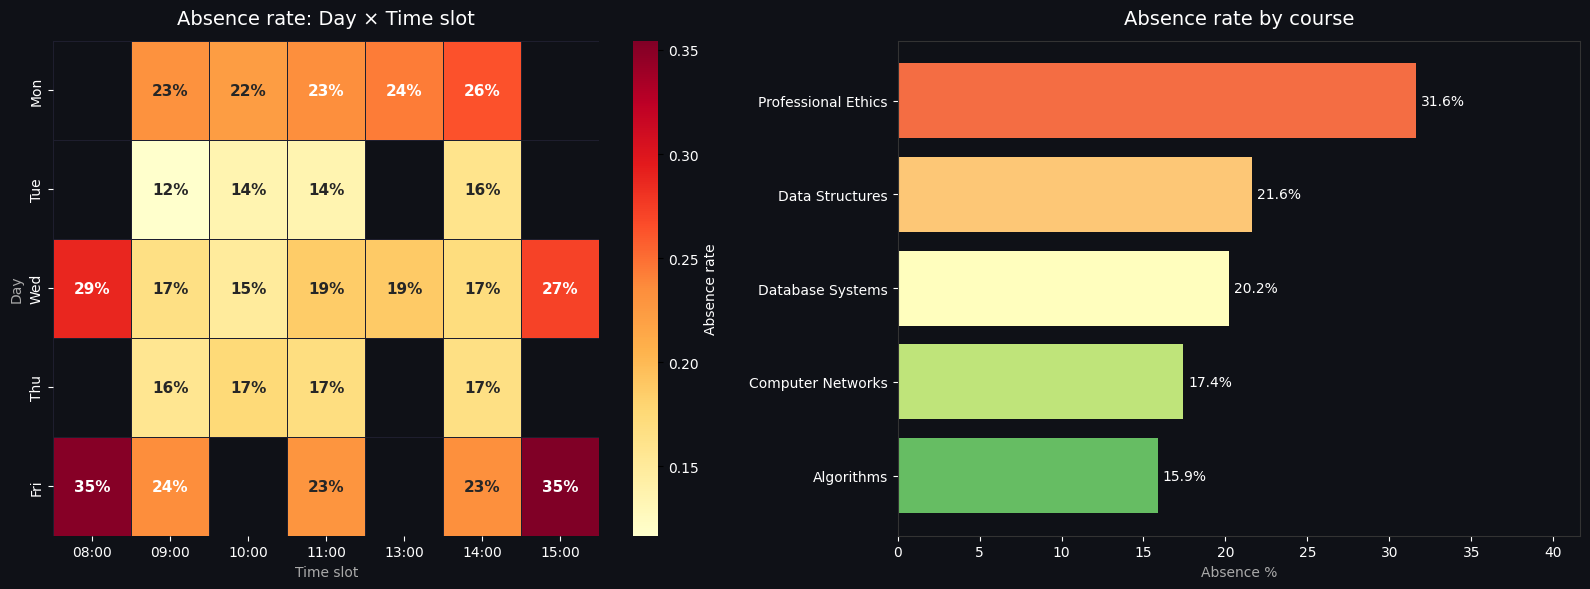

In [9]:
#Block 2: Time & Course Patterns (Heatmaps)

BG = '#0f1117'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
for ax in axes: ax.set_facecolor(BG)

pivot = df.groupby(['day_num','time'])['is_absent'].mean().unstack()
pivot.index = ['Mon','Tue','Wed','Thu','Fri']
sns.heatmap(pivot, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.0%', linewidths=0.5, linecolor='#1e1e2e',
            cbar_kws={'label': 'Absence rate'}, annot_kws={'size':11,'weight':'bold'})
axes[0].set_title('Absence rate: Day × Time slot', color='white', fontsize=14, pad=12)
axes[0].set_xlabel('Time slot', color='#aaa'); axes[0].set_ylabel('Day', color='#aaa')
axes[0].tick_params(colors='white')
cbar = axes[0].collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

course_abs = df.groupby('course_name')['is_absent'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(course_abs)))
bars = axes[1].barh(course_abs.index, course_abs.values*100, color=colors)
for bar, val in zip(bars, course_abs.values):
    axes[1].text(val*100+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1%}', va='center', color='white', fontsize=10)
axes[1].set_title('Absence rate by course', color='white', fontsize=14, pad=12)
axes[1].set_xlabel('Absence %', color='#aaa')
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')
axes[1].set_xlim(0, course_abs.max()*100 + 10)
plt.tight_layout()
plt.show()

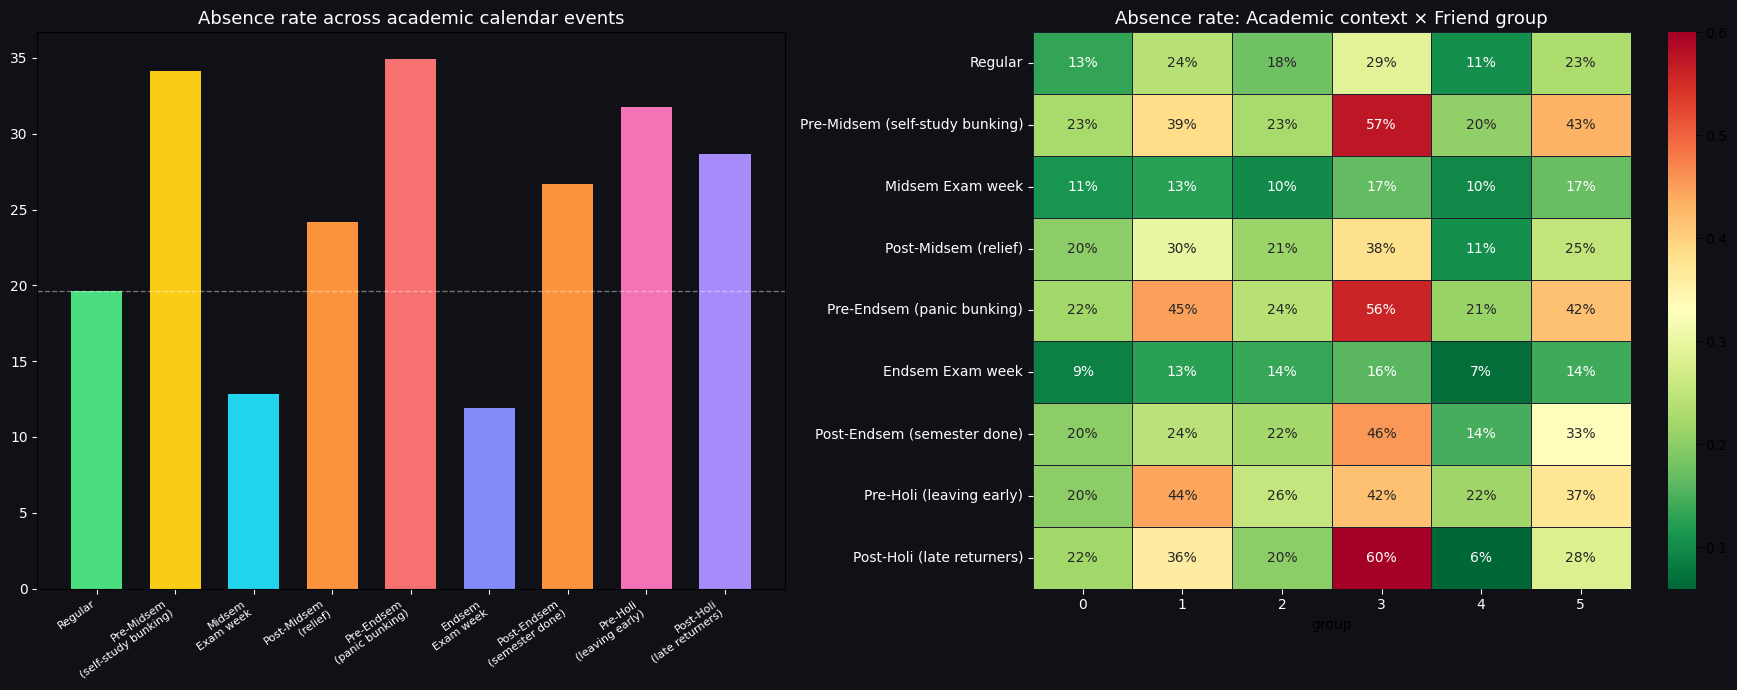

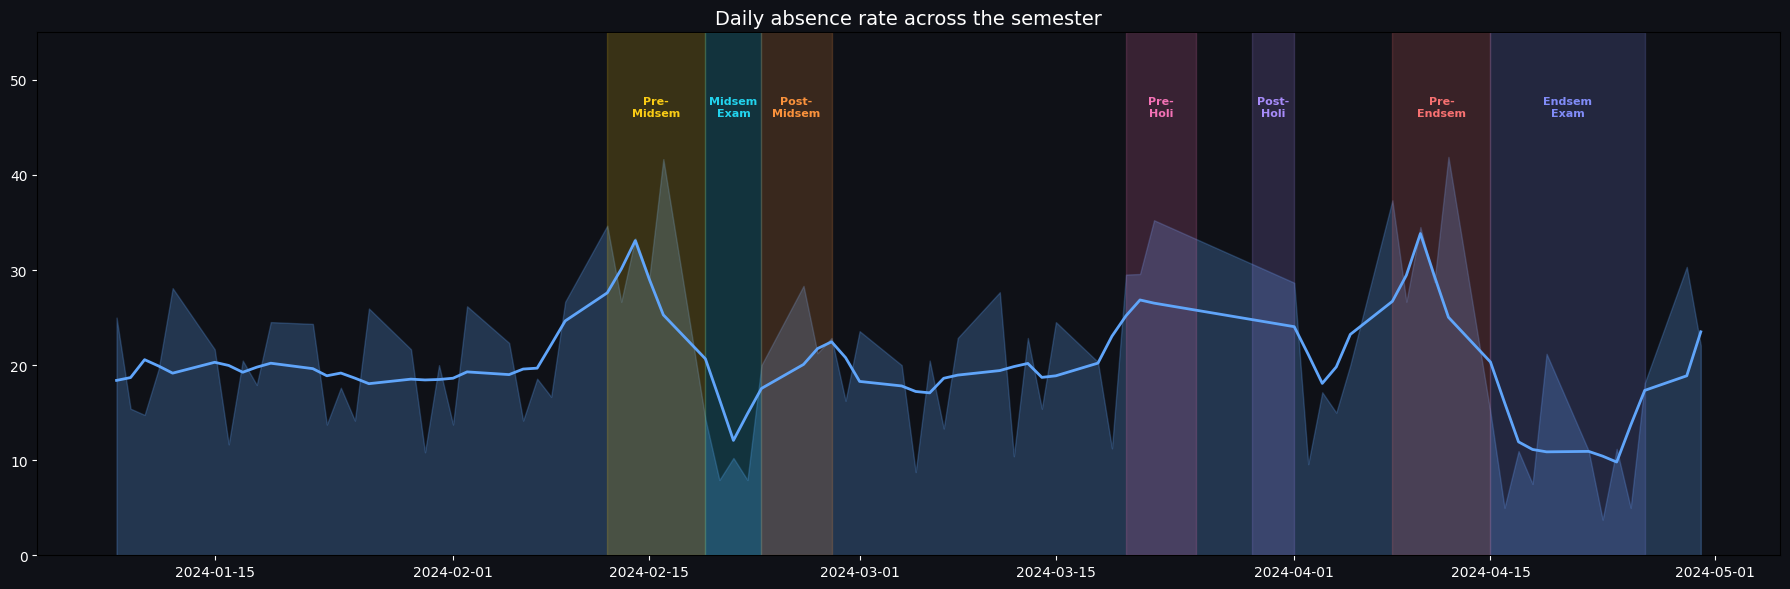

In [10]:
#Block 3: Academic Context & Timeline

CONTEXT_ORDER = ['regular','pre_midsem','midsem_exam','post_midsem','pre_endsem','endsem_exam','post_endsem','pre_holi','post_holi']
CONTEXT_LABELS = {'regular': 'Regular', 'pre_midsem': 'Pre-Midsem\n(self-study bunking)', 'midsem_exam': 'Midsem\nExam week', 'post_midsem': 'Post-Midsem\n(relief)', 'pre_endsem': 'Pre-Endsem\n(panic bunking)', 'endsem_exam': 'Endsem\nExam week', 'post_endsem': 'Post-Endsem\n(semester done)', 'pre_holi': 'Pre-Holi\n(leaving early)', 'post_holi': 'Post-Holi\n(late returners)'}
CONTEXT_COLORS = {'regular': '#4ade80', 'pre_midsem': '#facc15', 'midsem_exam': '#22d3ee', 'post_midsem': '#fb923c', 'pre_endsem': '#f87171', 'endsem_exam': '#818cf8', 'post_endsem': '#fb923c', 'pre_holi': '#f472b6', 'post_holi': '#a78bfa'}

# FIGURE 2
ctx_abs = df.groupby('context')['is_absent'].mean().reindex([c for c in CONTEXT_ORDER if c in df['context'].unique()])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG)
for ax in axes: ax.set_facecolor(BG)

bars = axes[0].bar(range(len(ctx_abs)), ctx_abs.values * 100, color=[CONTEXT_COLORS[c] for c in ctx_abs.index], width=0.65, edgecolor='none')
reg_val = ctx_abs.get('regular', 0) * 100
axes[0].axhline(reg_val, color='white', linewidth=1, linestyle='--', alpha=0.4)
axes[0].set_xticks(range(len(ctx_abs)))
axes[0].set_xticklabels([CONTEXT_LABELS[c] for c in ctx_abs.index], rotation=35, ha='right', color='white', fontsize=8)
axes[0].set_title('Absence rate across academic calendar events', color='white', fontsize=13)
axes[0].tick_params(colors='white')

hm_data = df.groupby(['context','group'])['is_absent'].mean().unstack().reindex([c for c in CONTEXT_ORDER if c in df['context'].unique()])
hm_data.index = [CONTEXT_LABELS[c].replace('\n',' ') for c in hm_data.index]
sns.heatmap(hm_data, ax=axes[1], cmap='RdYlGn_r', annot=True, fmt='.0%', linewidths=0.5, linecolor='#1e1e2e')
axes[1].set_title('Absence rate: Academic context × Friend group', color='white', fontsize=13)
axes[1].tick_params(colors='white')
plt.tight_layout(); plt.show()

# FIGURE 3
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
df['date_dt'] = pd.to_datetime(df['date'])
daily = df.groupby('date_dt')['is_absent'].mean().reset_index()
daily['rolling'] = daily['is_absent'].rolling(5, center=True, min_periods=1).mean()
ax.fill_between(daily['date_dt'], daily['is_absent']*100, alpha=0.25, color='#60a5fa')
ax.plot(daily['date_dt'], daily['rolling']*100, color='#60a5fa', linewidth=2, label='Daily absence % (5-day avg)')

def shade_region(ax, start, end, color, label, ypos=45):
    ax.axvspan(start, end, alpha=0.18, color=color)
    ax.text(start + (end - start)/2, ypos, label, ha='center', color=color, fontsize=8, fontweight='bold', va='bottom')

shade_region(ax, ACADEMIC_EVENTS['midsem_start'] - pd.Timedelta(days=PRE_EXAM_DAYS), ACADEMIC_EVENTS['midsem_start'], '#facc15', 'Pre-\nMidsem', 46)
shade_region(ax, ACADEMIC_EVENTS['midsem_start'], ACADEMIC_EVENTS['midsem_end'], '#22d3ee', 'Midsem\nExam', 46)
shade_region(ax, ACADEMIC_EVENTS['midsem_end'], ACADEMIC_EVENTS['midsem_end'] + pd.Timedelta(days=POST_EXAM_DAYS), '#fb923c', 'Post-\nMidsem', 46)
shade_region(ax, ACADEMIC_EVENTS['holi_start'] - pd.Timedelta(days=PRE_VAC_DAYS), ACADEMIC_EVENTS['holi_start'], '#f472b6', 'Pre-\nHoli', 46)
shade_region(ax, ACADEMIC_EVENTS['holi_end'], ACADEMIC_EVENTS['holi_end'] + pd.Timedelta(days=POST_VAC_DAYS), '#a78bfa', 'Post-\nHoli', 46)
shade_region(ax, ACADEMIC_EVENTS['endsem_start'] - pd.Timedelta(days=PRE_EXAM_DAYS), ACADEMIC_EVENTS['endsem_start'], '#f87171', 'Pre-\nEndsem', 46)
shade_region(ax, ACADEMIC_EVENTS['endsem_start'], ACADEMIC_EVENTS['endsem_end'], '#818cf8', 'Endsem\nExam', 46)

ax.set_title('Daily absence rate across the semester', color='white', fontsize=14); ax.tick_params(colors='white'); ax.set_ylim(0, 55)
plt.tight_layout(); plt.show()

Building co-absence network...


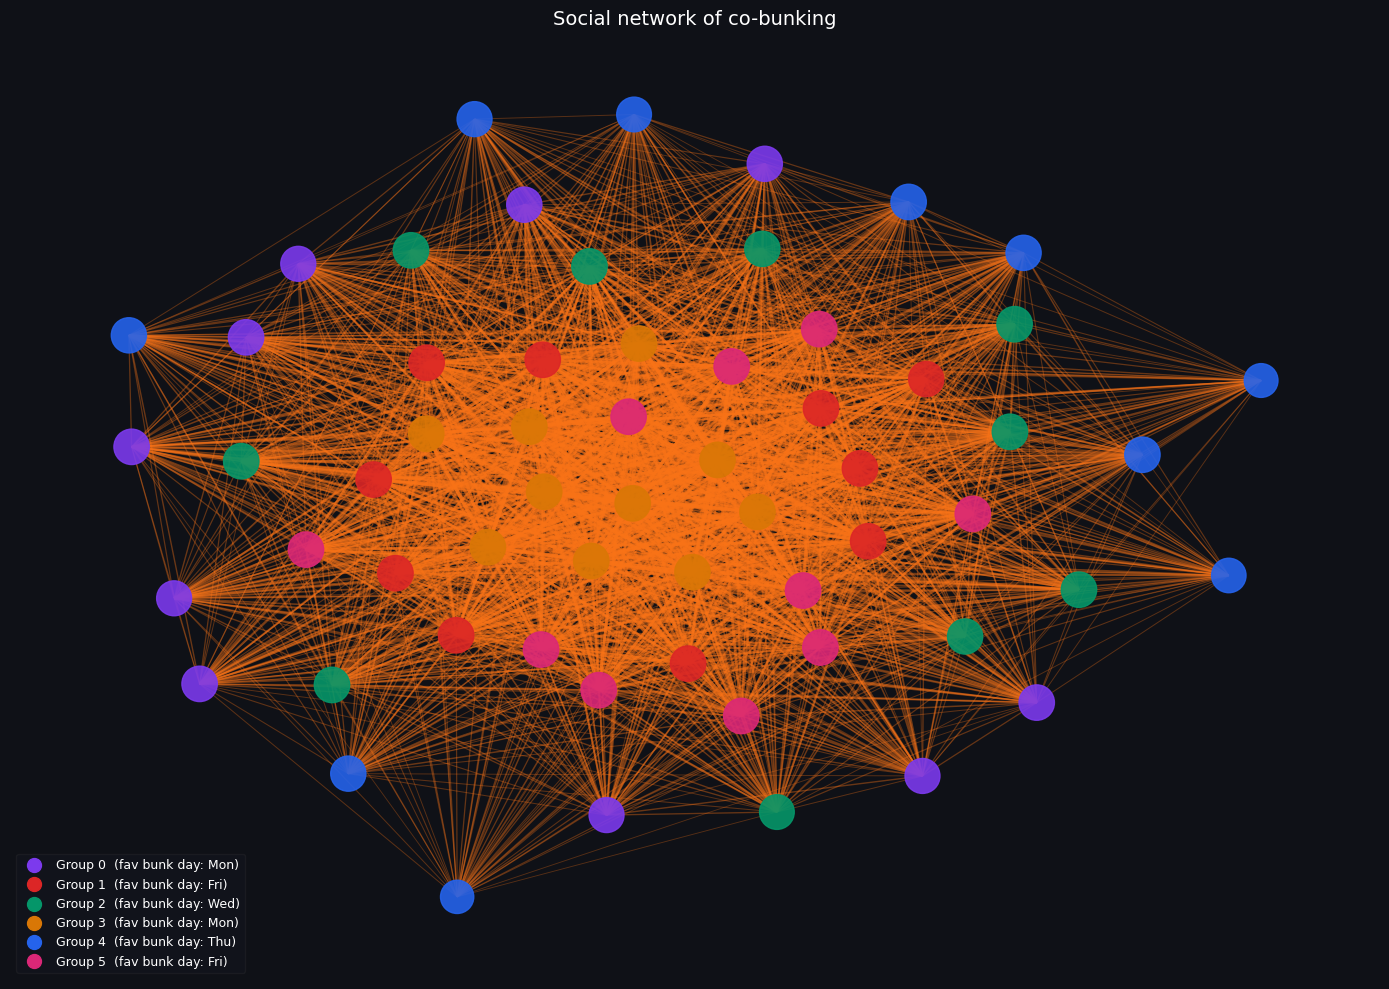

In [11]:
#Block 4: Social Network Analysis

print("Building co-absence network...")
slots = df[df['is_absent']==1].groupby(['date','course_code','time'])['student_id'].apply(list)
edge_weights = {}
for absentees in slots:
    if len(absentees) < 2: continue
    for i in range(len(absentees)):
        for j in range(i+1, len(absentees)):
            a,b = sorted([absentees[i], absentees[j]])
            edge_weights[(a,b)] = edge_weights.get((a,b),0) + 1

THRESHOLD = 6
strong_edges = {k:v for k,v in edge_weights.items() if v >= THRESHOLD}
G = nx.Graph()
G.add_nodes_from(student_ids)
for (a,b),w in strong_edges.items(): G.add_edge(a,b,weight=w)

sid_to_group = dict(zip(student_df['student_id'], student_df['group']))
fig, ax = plt.subplots(figsize=(14,10))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
pos = nx.spring_layout(G, seed=42, k=0.5)

edge_list = list(G.edges(data=True))
if edge_list:
    max_w = max(d['weight'] for _,_,d in edge_list)
    for u,v,d in edge_list:
        w = d['weight']
        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], ax=ax, width=0.4+2.5*(w/max_w), alpha=0.25+0.55*(w/max_w), edge_color='#f97316')

node_colors = [group_color_map[sid_to_group[n]] for n in G.nodes()]
deg = dict(G.degree())
max_deg = max(deg.values()) if deg else 1
node_sizes = [150 + 500*(deg[n]/max_deg) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)

for grp, col in group_color_map.items():
    ax.scatter([], [], c=col, s=100, label=f'Group {grp}  (fav bunk day: {group_fav_bunk_day[grp]})')
ax.legend(loc='lower left', framealpha=0.2, labelcolor='white', facecolor='#1e1e2e', edgecolor='#444', fontsize=9)
ax.set_title('Social network of co-bunking', color='white', fontsize=14); ax.axis('off')
plt.tight_layout(); plt.show()

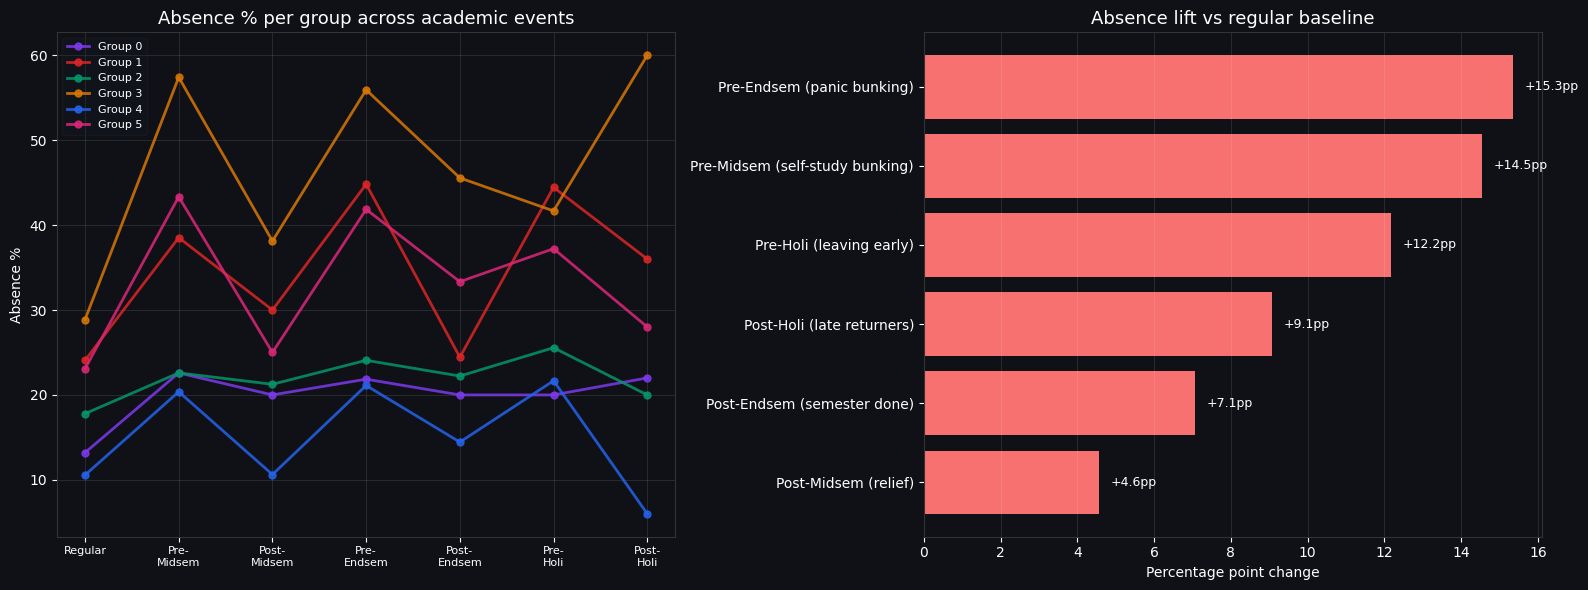


=== STATISTICAL RESULTS ===

--- Chi-Square Test (Day of Week vs Absence) ---
H0: Absence rate is independent of the day of the week (no significant difference across days)
H1: Absence rate is NOT independent of the day of the week (significant difference exists)
Chi-square statistic: 313.0396
p-value: 0.0000
Result: REJECT H0 → Day of week significantly affects student absence (p < 0.05)

--- One-Way ANOVA Test (Friend Group vs Absence Rate) ---
H0: All 6 friend groups have the same mean absence rate (μ1 = μ2 = μ3 = μ4 = μ5 = μ6)
H1: At least one friend group has a significantly different mean absence rate
F-statistic: 206.9640
p-value: 0.0000
Result: REJECT H0 → Friend group membership significantly affects absence rate (p < 0.05)

=== ABSENCE RATE BY CONTEXT ===
              mean  count
context                 
regular      19.6  13860
pre_midsem   34.1   1620
midsem_exam  12.8   1620
post_midsem  24.2    960
pre_endsem   34.9   1620
endsem_exam  11.9   3240
post_endsem  26.7    5

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Assuming file_path is available from previous cells, if not, it needs to be defined.
# For robustness, we re-declare it here if the kernel state might be inconsistent.
file_path = "/mnt/user-data/outputs/attendance_dataset_v2.csv"
df = pd.read_csv(file_path)

#Block 5: Statistical Analysis & Final Summary

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.patch.set_facecolor(BG)
for ax in axes: ax.set_facecolor(BG)

target_contexts = ['regular','pre_midsem','post_midsem','pre_endsem','post_endsem','pre_holi','post_holi']
target_labels = ['Regular','Pre-\nMidsem','Post-\nMidsem','Pre-\nEndsem','Post-\nEndsem','Pre-\nHoli','Post-\nHoli']
gr_ctx = df[df['context'].isin(target_contexts)].groupby(['group','context'])['is_absent'].mean().reset_index()

for grp, col in group_color_map.items():
    g = gr_ctx[gr_ctx['group']==grp].set_index('context')['is_absent'].reindex(target_contexts)
    axes[0].plot(range(len(target_contexts)), g.values*100, color=col, linewidth=2, marker='o', markersize=5, label=f'Group {grp}', alpha=0.85)

axes[0].set_xticks(range(len(target_contexts)))
axes[0].set_xticklabels(target_labels, color='white', fontsize=8)
axes[0].set_ylabel('Absence %', color='white') # Changed from '#aaa' to 'white'
axes[0].set_title('Absence % per group across academic events', color='white', fontsize=13)
axes[0].tick_params(colors='white')
for sp in axes[0].spines.values(): sp.set_edgecolor('#333')
axes[0].grid(alpha=0.1, color='white')
axes[0].legend(fontsize=8, framealpha=0.2, labelcolor='white', facecolor='#1e1e2e', edgecolor='#333')

regular_rate = df[df['context']=='regular']['is_absent'].mean()
lift = {CONTEXT_LABELS[ctx].replace('\n',' '): (df[df['context']==ctx]['is_absent'].mean() - regular_rate) * 100 for ctx in target_contexts[1:]}
lift_series = pd.Series(lift).sort_values(ascending=True)
bars = axes[1].barh(lift_series.index, lift_series.values, color=['#4ade80' if v < 0 else '#f87171' for v in lift_series.values])
for bar, val in zip(bars, lift_series.values):
    axes[1].text(val + (0.3 if val>=0 else -0.3), bar.get_y()+bar.get_height()/2, f'{val:+.1f}pp', va='center', color='white', fontsize=9)
axes[1].set_title('Absence lift vs regular baseline', color='white', fontsize=13)
axes[1].set_xlabel('Percentage point change', color='white') # Changed from '#aaa' to 'white'
axes[1].tick_params(colors='white')
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')
axes[1].grid(axis='x', alpha=0.1, color='white')

plt.tight_layout(); plt.show()

print("\n=== STATISTICAL RESULTS ===")
day_ct = df.groupby('day')['is_absent'].agg(['sum','count'])
chi2, p, _, _ = stats.chi2_contingency(day_ct[['sum', 'count']].assign(p=day_ct['count']-day_ct['sum'])[['sum','p']].values)

print("\n--- Chi-Square Test (Day of Week vs Absence) ---")
print("H0: Absence rate is independent of the day of the week (no significant difference across days)")
print("H1: Absence rate is NOT independent of the day of the week (significant difference exists)")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
if p < 0.05:
    print("Result: REJECT H0 → Day of week significantly affects student absence (p < 0.05)")
else:
    print("Result: FAIL TO REJECT H0 → No significant difference in absence across days (p >= 0.05)")

student_abs = df.groupby(['student_id','group'])['is_absent'].mean().reset_index()
f, pf = stats.f_oneway(*[student_abs[student_abs['group']==g]['is_absent'].values for g in range(6)])

print("\n--- One-Way ANOVA Test (Friend Group vs Absence Rate) ---")
print("H0: All 6 friend groups have the same mean absence rate (μ1 = μ2 = μ3 = μ4 = μ5 = μ6)")
print("H1: At least one friend group has a significantly different mean absence rate")
print(f"F-statistic: {f:.4f}")
print(f"p-value: {pf:.4f}")
if pf < 0.05:
    print("Result: REJECT H0 → Friend group membership significantly affects absence rate (p < 0.05)")
else:
    print("Result: FAIL TO REJECT H0 → No significant difference in absence across groups (p >= 0.05)")

ctx_summary = df.groupby('context')['is_absent'].agg(['mean','count']).reindex(CONTEXT_ORDER)
ctx_summary['mean'] = (ctx_summary['mean']*100).round(1)
print("\n=== ABSENCE RATE BY CONTEXT ===\n", ctx_summary)
print(f"\nDefaulters: {(df.groupby('student_id')['is_absent'].mean() > 0.25).sum()}/{N_STUDENTS}")

---

## ✅ Conclusion

The Smart Attendance Pattern Analyzer demonstrates how data, context, and visualization together can reveal powerful insights into student behavior.  
By turning raw attendance logs into meaningful patterns, this project proves that **analytics can transform everyday academic routines into actionable knowledge** — closing the loop between data and decision-making.
